# Clasificador de Anillos Galácticos — Zoobot v7 Etapa 2
## Subclasificación: inner vs outer vs inner+outer

### Pipeline de 2 etapas:
- **Etapa 1** : none vs ring → F1 = 1.00 
- **Etapa 2** : inner vs outer vs inner+outer 

### Estrategia:
- Solo entrenamos con galaxias que **tienen** anillo
- Subsamplear inner (~804) a ~350 para balancear con outer (~178) (propuesta que esta comentada)
- FocalLoss + ReduceLROnPlateau


---
# Parte 1: Instalación y configuración

> **Nota:** Ejecutar esta celda solo la primera vez o si falta algún paquete.
> Después de instalar Zoobot, **reinstalar PyTorch con CUDA** si tienes GPU.

In [1]:
'''
# ============================================================
# Instalación de dependencias
# ============================================================
# 1. Instalar Zoobot (puede sobreescribir PyTorch CPU-only)
!pip install zoobot

# 2. IMPORTANTE: Reinstalar PyTorch con CUDA para tu GPU
#    Ajusta cu126 a tu versión de CUDA (nvcc --version)
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

# 3. Dependencias adicionales
!pip install timm plotly nbformat opencv-python-headless pytorch-grad-cam

# Verificar CUDA
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
'''
print("Celda de instalación (descomenta para ejecutar)")

Celda de instalación (descomenta para ejecutar)


---
# Parte 2: Imports globales

In [2]:
# ============================================================
# Imports
# ============================================================
import os
import io
import re
import cv2
import time
import glob
import shutil
import random
import pathlib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from astropy.io import fits
from astropy.visualization import (
    make_lupton_rgb, ZScaleInterval, MinMaxInterval, LogStretch
)

from scipy import ndimage
from scipy.signal import find_peaks, peak_prominences, savgol_filter
from skimage import filters, measure, morphology, segmentation
from skimage.draw import ellipse_perimeter
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label, regionprops
from skimage.morphology import (
    binary_closing, binary_dilation, binary_erosion, binary_opening, disk
)

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, roc_auc_score, roc_curve
)

import matplotlib.patches as mpatches
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from matplotlib.patches import Ellipse

import timm

import requests

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'

print("Imports completados exitosamente")

Imports completados exitosamente


---
# Parte 3: Configuración global

> **⚠️ ADAPTAR:** Modifica las rutas a tus archivos y directorios según tu entorno.

In [3]:
# ============================================================
# CONFIGURACIÓN — ADAPTAR RUTAS AQUÍ
# ============================================================

# --- Rutas de entrada ---
CSV_DATASET      = "../Dataset/dataset.csv"
CSV_MANGA        = "../Dataset/MaNGA_rings.csv"
CSV_CSRG         = "../Dataset/CSRG_Buta.csv"
FITS_GRZ_DIR     = Path("../Images_GRZ")

# --- Rutas de salida ---
DATA_DIR         = Path("./galaxy_images")
OUTPUT_DIR       = Path("./outputs")
DATASET_NAME     = "dataset_zoobot_rings_3cls"

# --- Parámetros de imagen ---
PIXSCALE  = 0.262           # arcsec/pixel (Legacy Survey)
SIZE      = 224
BANDS     = "grz"

# --- Transformación FITS → PNG ---
TRANSFORM = "rgi_lognorm"

# --- Legacy Survey ---
LAYER     = "ls-dr10"
TIMEOUT_S = 60
WORKERS   = 8
SLEEP_S   = 0.05

# --- Clases (4 clases principales) ---
# v7 Etapa 2: Solo anillos (sin "none")
RING_CODES = {4: "inner", 8: "outer", 12: "inner+outer"}
RING_TYPE  = ["inner", "outer", "inner+outer"]
ANILLOS_LABEL = RING_CODES
VALID_CODES   = {4, 8, 12}

# --- Entrenamiento ---
BATCH_SIZE    = 64
IMAGE_SIZE    = 224
SEED          = 42
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Constantes morfológicas ---
PLATE_SCALE = PIXSCALE

# Crear directorios
for d in [DATA_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
for cls_name in RING_TYPE:
    (DATA_DIR / cls_name).mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = "download_log.csv"

print(f"Device: {DEVICE}")
print(f"Clases: {RING_TYPE}")
print(f"FITS GRZ dir: {FITS_GRZ_DIR}")

Device: cuda
Clases: ['inner', 'outer', 'inner+outer']
FITS GRZ dir: ..\Images_GRZ


---
# Parte 4: Funciones auxiliares

## 4.1 Utilidades de conversión y URLs

In [4]:
def to_int(x, default=0):
    """Convierte un valor a entero de forma segura."""
    try:
        return int(float(x))
    except Exception:
        return default

def legacy_cutout_url(ra, dec, pixscale=PIXSCALE, size=SIZE, bands=BANDS, layer=LAYER):
    return (f"https://www.legacysurvey.org/viewer/fits-cutout"
            f"?ra={ra}&dec={dec}&layer={layer}"
            f"&pixscale={pixscale}&size={size}&bands={bands}")

def legacy_jpg_url(ra, dec, pixscale=PIXSCALE, size=SIZE, layer=LAYER):
    return (f"https://www.legacysurvey.org/viewer/cutout.jpg"
            f"?ra={ra}&dec={dec}&layer={layer}"
            f"&pixscale={pixscale}&size={size}")

print("Utilidades cargadas")

Utilidades cargadas


## 4.2 Transformaciones de imagen FITS → RGB

Se implementan múltiples transformaciones para procesar las imágenes astronómicas de 3 bandas:
- **RGI Stack**: Composición directa r, g, z → RGB
- **RGI LogNorm**: Normalización logarítmica suave (recomendada)
- **Unsharp**: Realce de bordes por enmascaramiento de enfoque
- **PCA**: Reducción de dimensionalidad para maximizar contraste
- **Log N Scale**: Escalado logarítmico clásico

In [5]:
class Transformations:
    @staticmethod
    def log_n_scale_transform(img_data, log_a=1000, clip_mode='minmax', med_val=20):
        if img_data is None or img_data.size == 0:
            return None
        img = img_data.astype(np.float64)
        if clip_mode == 'median':
            vmin = max(np.nanmedian(img) - med_val, 0)
            vmax = np.nanpercentile(img, 99.9)
        else:
            vmin, vmax = np.nanpercentile(img, [0.5, 99.5])
        img = np.clip(img, vmin, vmax)
        if vmax > vmin:
            img = (img - vmin) / (vmax - vmin)
        img = np.log10(1 + log_a * img) / np.log10(1 + log_a)
        return np.clip(img * 255, 0, 255).astype(np.uint8)

    @staticmethod
    def rgi_stack_transform(r, g, z):
        channels = []
        for band in [r, g, z]:
            b = band.astype(np.float64)
            p1, p99 = np.nanpercentile(b, [1, 99])
            b = np.clip(b, p1, p99)
            b = (b - p1) / max(p99 - p1, 1e-10)
            channels.append((b * 255).astype(np.uint8))
        return np.stack(channels, axis=-1)

    @staticmethod
    def rgi_lognorm_transform(r, g, z, log_a=1000):
        channels = []
        for band in [r, g, z]:
            ch = Transformations.log_n_scale_transform(band, log_a=log_a)
            if ch is None:
                return None
            channels.append(ch)
        return np.stack(channels, axis=-1)

    @staticmethod
    def unsharp_transform(r, g, z, sigma=5, strength=2.0):
        channels = []
        for band in [r, g, z]:
            b = band.astype(np.float64)
            p1, p99 = np.nanpercentile(b, [1, 99])
            b = np.clip(b, p1, p99)
            b = (b - p1) / max(p99 - p1, 1e-10)
            blurred = gaussian(b, sigma=sigma)
            sharp = b + strength * (b - blurred)
            sharp = np.clip(sharp, 0, 1)
            channels.append((sharp * 255).astype(np.uint8))
        return np.stack(channels, axis=-1)

    @staticmethod
    def pca_transform(r, g, z):
        bands = np.stack([r.flatten(), g.flatten(), z.flatten()], axis=1).astype(np.float64)
        bands -= bands.mean(axis=0)
        cov = np.cov(bands, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        idx = eigenvalues.argsort()[::-1]
        eigenvectors = eigenvectors[:, idx]
        pca = bands @ eigenvectors
        channels = []
        for i in range(3):
            ch = pca[:, i].reshape(r.shape)
            p1, p99 = np.nanpercentile(ch, [1, 99])
            ch = np.clip(ch, p1, p99)
            ch = (ch - p1) / max(p99 - p1, 1e-10)
            channels.append((ch * 255).astype(np.uint8))
        return np.stack(channels, axis=-1)

    @staticmethod
    def apply_transform(r_band, g_band, z_band, method="rgi_lognorm"):
        methods = {
            "rgi_stack":    lambda: Transformations.rgi_stack_transform(r_band, g_band, z_band),
            "rgi_lognorm":  lambda: Transformations.rgi_lognorm_transform(r_band, g_band, z_band),
            "unsharp":      lambda: Transformations.unsharp_transform(r_band, g_band, z_band),
            "pca":          lambda: Transformations.pca_transform(r_band, g_band, z_band),
            "log_n_scale":  lambda: Transformations.rgi_lognorm_transform(r_band, g_band, z_band, log_a=500),
        }
        if method not in methods:
            print(f"Método desconocido: {method}, usando rgi_lognorm")
            method = "rgi_lognorm"
        try:
            return methods[method]()
        except Exception as e:
            print(f"Error en transformación {method}: {e}")
            return None

print("Transformaciones cargadas")

Transformaciones cargadas


In [6]:
# ============================================================
# Cargar catálogo — solo galaxias CON anillo
# ============================================================
df_sdss = pd.read_csv(CSV_DATASET)
df_sdss['objID'] = df_sdss['objID'].astype(np.int64)
print(f"Catálogo total: {len(df_sdss)} galaxias")

df_sdss['anillos_int'] = df_sdss['anillos'].apply(lambda x: to_int(x, -1))
df_sdss = df_sdss[df_sdss['anillos_int'].isin(VALID_CODES)].copy()
df_sdss['ring_type'] = df_sdss['anillos_int'].map(RING_CODES)

print(f"\nGalaxias con anillo: {len(df_sdss)}")
print(df_sdss['ring_type'].value_counts())

objid_to_class = dict(zip(df_sdss['objID'], df_sdss['ring_type']))

Catálogo total: 8528 galaxias

Galaxias con anillo: 1415
ring_type
inner          857
inner+outer    372
outer          186
Name: count, dtype: int64


## 5.2 Procesar FITS locales (Images_GRZ) → PNG por clase

Lee los archivos FITS de 3 bandas (g, r, z) de tu carpeta local,
aplica la transformación seleccionada y guarda como PNG organizado por clase.

In [7]:
# ============================================================
# PROCESAR FITS LOCALES (Images_GRZ) → PNG por clase
# ============================================================
fits_files = sorted(FITS_GRZ_DIR.glob("*_grz.fits"))
print(f"FITS encontrados en {FITS_GRZ_DIR}: {len(fits_files)}")

if len(fits_files) == 0:
    print("  No se encontraron archivos *_grz.fits")
    print(f"   Verifica la ruta: {FITS_GRZ_DIR.resolve()}")
else:
    processed, skipped_no_class, skipped_exists, errors = 0, 0, 0, 0

    for fits_path in fits_files:
        try:
            objid = int(fits_path.stem.replace("_grz", ""))
            if objid not in objid_to_class:
                skipped_no_class += 1
                continue

            ring_class = objid_to_class[objid]
            dest_png = DATA_DIR / ring_class / f"{objid}_{ring_class}.png"

            if dest_png.exists() and dest_png.stat().st_size > 0:
                skipped_exists += 1
                processed += 1
                continue

            with fits.open(fits_path) as hdul:
                data = hdul[0].data
                if data is None or data.ndim < 3:
                    errors += 1
                    continue
                g_band, r_band, z_band = data[0], data[1], data[2]
                img = Transformations.apply_transform(r_band, g_band, z_band, TRANSFORM)

                if img is not None:
                    pil_img = Image.fromarray(img)
                    if pil_img.size != (IMAGE_SIZE, IMAGE_SIZE):
                        pil_img = pil_img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
                    pil_img.save(dest_png)
                    processed += 1
                else:
                    errors += 1
        except Exception as e:
            errors += 1
            if errors <= 3:
                print(f"  Error en {fits_path.name}: {e}")

        total = processed + skipped_no_class + errors
        if total % 2000 == 0 and total > 0:
            print(f"  Progreso: {total}/{len(fits_files)}")

    print(f"\n{'='*50}")
    print(f"RESULTADO:")
    print(f"  Procesados:     {processed} ({skipped_exists} ya existían)")
    print(f"  Sin clase CSV:  {skipped_no_class}")
    print(f"  Errores:        {errors}")
    print(f"\nImágenes por clase:")
    total_imgs = 0
    for cls_name in RING_TYPE:
        n = len(list((DATA_DIR / cls_name).glob("*.png")))
        total_imgs += n
        print(f"  {cls_name:15s}: {n}")
    print(f"  TOTAL:           {total_imgs}")

FITS encontrados en ..\Images_GRZ: 7678

RESULTADO:
  Procesados:     1329 (1329 ya existían)
  Sin clase CSV:  6349
  Errores:        0

Imágenes por clase:
  inner          : 804
  outer          : 178
  inner+outer    : 347
  TOTAL:           1329


---
# Parte 6: Análisis Exploratorio de Datos (EDA)

## 6.1 Distribución de clases

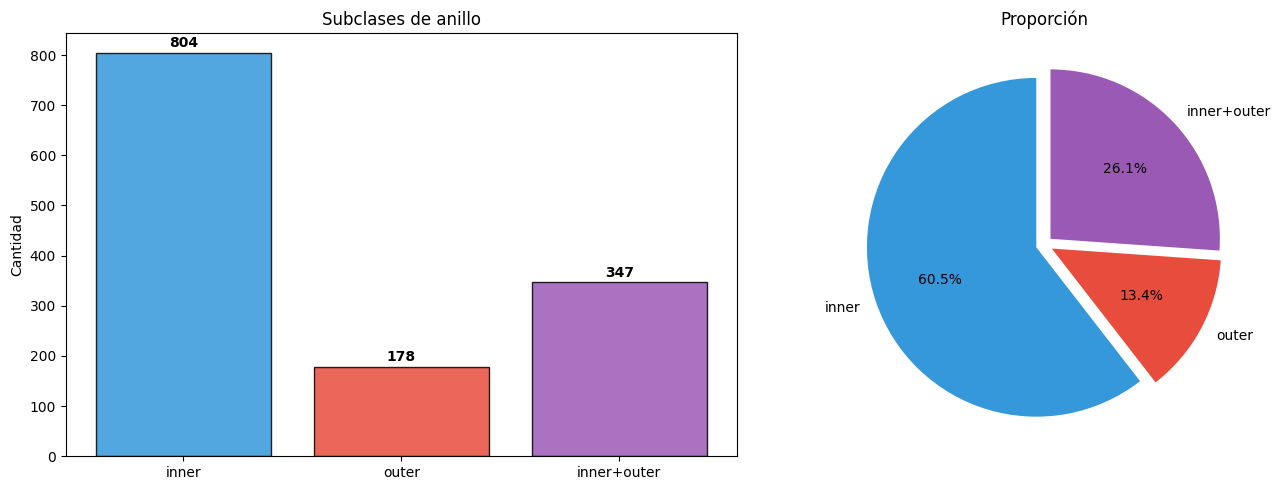

Ratio max:min = 4.5:1


In [8]:
# Distribución de subclases de anillo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = {cls: len(list((DATA_DIR / cls).glob("*.png"))) for cls in RING_TYPE}
colors = ['#3498db', '#e74c3c', '#9b59b6'][:len(counts)]
bars = axes[0].bar(counts.keys(), counts.values(), color=colors, edgecolor='black', alpha=0.85)
for bar, count in zip(bars, counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(count), ha='center', va='bottom', fontweight='bold')
axes[0].set_title("Subclases de anillo"); axes[0].set_ylabel("Cantidad")
axes[1].pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%',
           colors=colors, startangle=90, explode=[0.05]*len(counts))
axes[1].set_title("Proporción")
plt.tight_layout(); plt.show()
print(f"Ratio max:min = {max(counts.values())/max(min(counts.values()),1):.1f}:1")

## 6.2 Visualización de muestras por clase

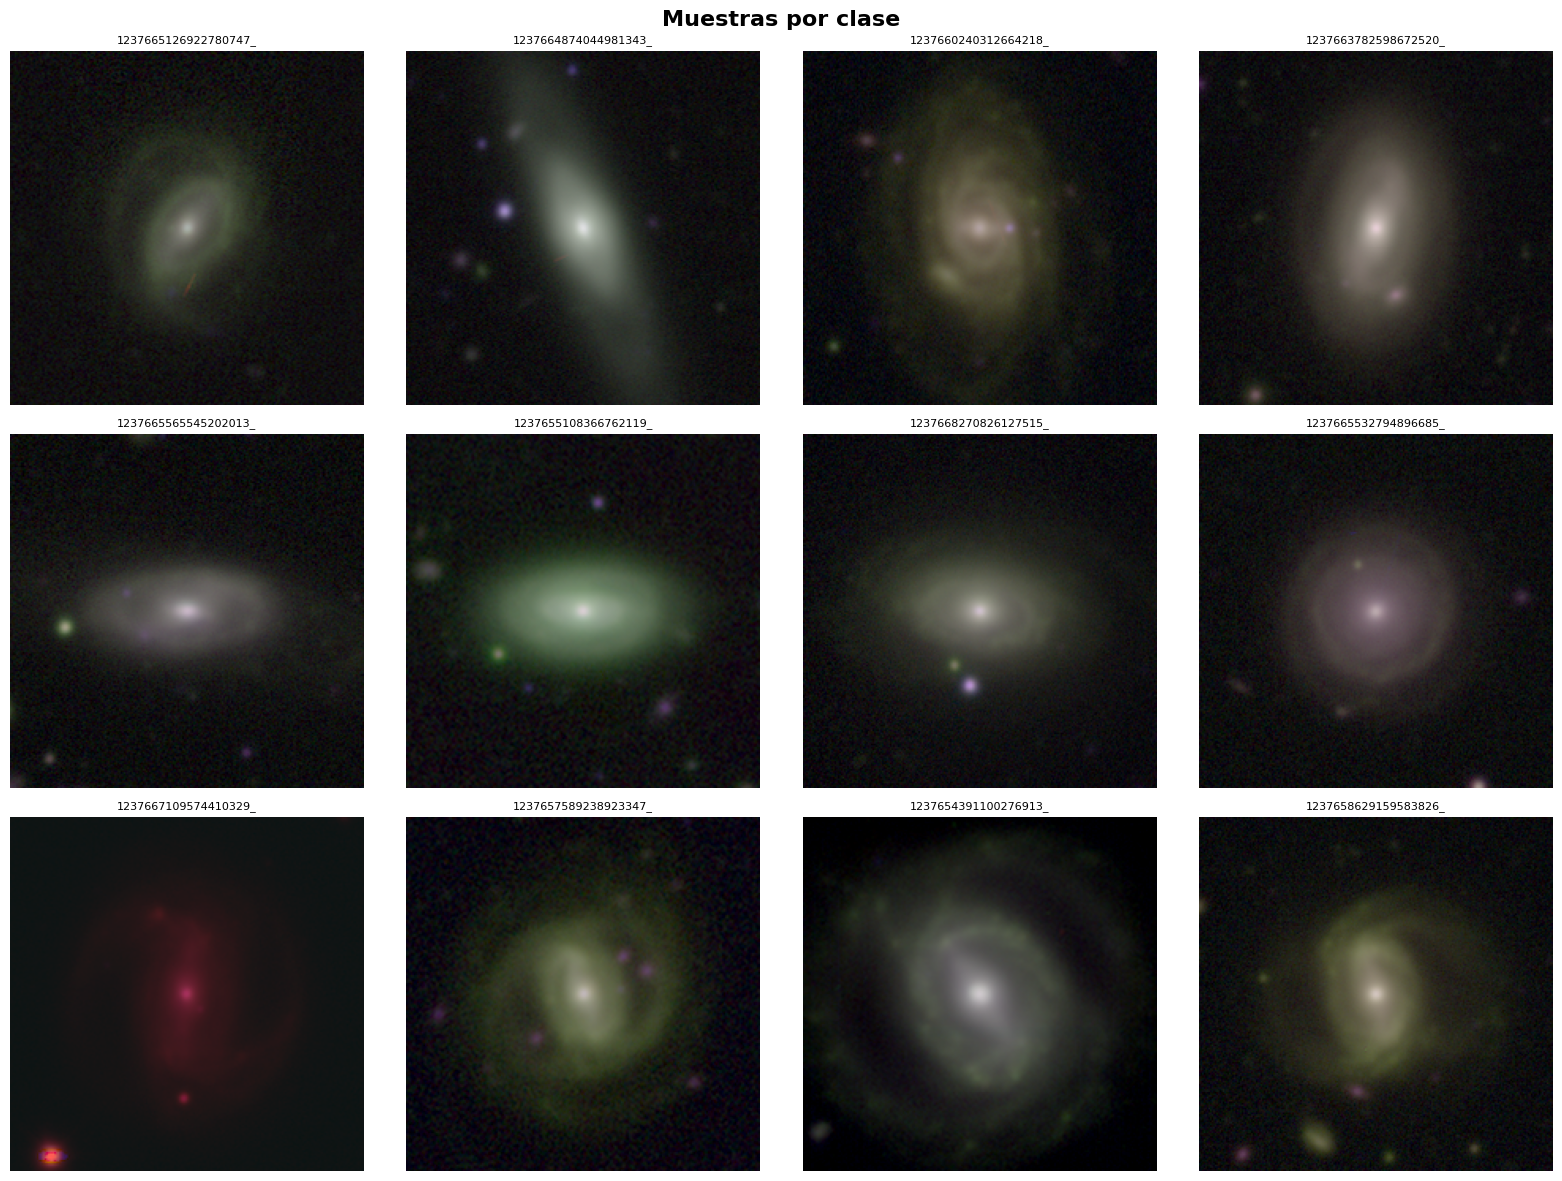

In [9]:
def plot_samples_by_class(data_dir, ring_types, samples_per_class=4):
    """Visualiza muestras aleatorias de cada clase."""
    fig, axs = plt.subplots(len(ring_types), samples_per_class,
                           figsize=(4*samples_per_class, 4*len(ring_types)))
    for i, cls in enumerate(ring_types):
        cls_dir = Path(data_dir) / cls
        imgs = list(cls_dir.glob("*.png"))
        if not imgs:
            continue
        samples = random.sample(imgs, min(samples_per_class, len(imgs)))
        for j, img_path in enumerate(samples):
            img = Image.open(img_path)
            axs[i, j].imshow(img)
            axs[i, j].axis("off")
            if j == 0:
                axs[i, j].set_ylabel(cls, fontsize=14, fontweight='bold', rotation=0,
                                    labelpad=60, va='center')
            axs[i, j].set_title(img_path.stem[:20], fontsize=8)
    plt.suptitle("Muestras por clase", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_samples_by_class(DATA_DIR, RING_TYPE)

---
# Parte 8: Preparación del dataset para entrenamiento

## 8.1 Split train/val y organización de carpetas

In [10]:
'''
# Split + subsamplear "inner" para equilibrar con "outer"
def create_dataset_folders(base_path, categories):
    base_path = Path(base_path)
    for split in ['train', 'val']:
        for cat in categories:
            (base_path / split / cat).mkdir(parents=True, exist_ok=True)

def split_and_subsample(source_dir, dest_base, categories,
                         val_fraction=0.2, seed=42, max_per_class=350):
    random.seed(seed); np.random.seed(seed)
    create_dataset_folders(dest_base, categories)
    for cat in categories:
        src = Path(source_dir) / cat
        imgs = sorted(src.glob("*.png"))
        random.shuffle(imgs)
        if len(imgs) > max_per_class:
            print(f"  {cat:15s}: {len(imgs)} -> subsampled to {max_per_class}")
            imgs = imgs[:max_per_class]
        else:
            print(f"  {cat:15s}: {len(imgs)} (kept all)")
        n_val = max(10, int(len(imgs) * val_fraction))
        val_imgs, train_imgs = imgs[:n_val], imgs[n_val:]
        for img in train_imgs:
            shutil.copy2(img, Path(dest_base) / "train" / cat / img.name)
        for img in val_imgs:
            shutil.copy2(img, Path(dest_base) / "val" / cat / img.name)
        print(f"  {'':15s}  -> {len(train_imgs)} train, {len(val_imgs)} val")

if Path(DATASET_NAME).exists():
    shutil.rmtree(DATASET_NAME)
print("Creando dataset de 3 clases...")
split_and_subsample(DATA_DIR, DATASET_NAME, RING_TYPE, max_per_class=350)
'''

'\n# Split + subsamplear "inner" para equilibrar con "outer"\ndef create_dataset_folders(base_path, categories):\n    base_path = Path(base_path)\n    for split in [\'train\', \'val\']:\n        for cat in categories:\n            (base_path / split / cat).mkdir(parents=True, exist_ok=True)\n\ndef split_and_subsample(source_dir, dest_base, categories,\n                         val_fraction=0.2, seed=42, max_per_class=350):\n    random.seed(seed); np.random.seed(seed)\n    create_dataset_folders(dest_base, categories)\n    for cat in categories:\n        src = Path(source_dir) / cat\n        imgs = sorted(src.glob("*.png"))\n        random.shuffle(imgs)\n        if len(imgs) > max_per_class:\n            print(f"  {cat:15s}: {len(imgs)} -> subsampled to {max_per_class}")\n            imgs = imgs[:max_per_class]\n        else:\n            print(f"  {cat:15s}: {len(imgs)} (kept all)")\n        n_val = max(10, int(len(imgs) * val_fraction))\n        val_imgs, train_imgs = imgs[:n_val], im

In [11]:
# Split train/val — SIN subsamplear, usar TODOS los datos
# FocalLoss + balance interno del Dataset manejan el desbalanceo
def create_dataset_folders(base_path, categories):
    base_path = Path(base_path)
    for split in ['train', 'val']:
        for cat in categories:
            (base_path / split / cat).mkdir(parents=True, exist_ok=True)

def split_dataset(source_dir, dest_base, categories, val_fraction=0.2, seed=42):
    random.seed(seed); np.random.seed(seed)
    create_dataset_folders(dest_base, categories)
    for cat in categories:
        src = Path(source_dir) / cat
        imgs = sorted(src.glob("*.png"))
        random.shuffle(imgs)
        n_val = max(10, int(len(imgs) * val_fraction))
        val_imgs, train_imgs = imgs[:n_val], imgs[n_val:]
        for img in train_imgs:
            shutil.copy2(img, Path(dest_base) / "train" / cat / img.name)
        for img in val_imgs:
            shutil.copy2(img, Path(dest_base) / "val" / cat / img.name)
        print(f"  {cat:15s}: {len(train_imgs)} train, {len(val_imgs)} val")

if Path(DATASET_NAME).exists():
    shutil.rmtree(DATASET_NAME)
print("Creando dataset con TODOS los datos...")
split_dataset(DATA_DIR, DATASET_NAME, RING_TYPE)

Creando dataset con TODOS los datos...
  inner          : 644 train, 160 val
  outer          : 143 train, 35 val
  inner+outer    : 278 train, 69 val


## 8.2 Dataset personalizado con augmentation y balanceo

In [12]:
class GalaxyDataset(Dataset):
    def __init__(self, root_dir, categories, transform=None, balance=True, target_count=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples, self.labels = [], []
        self.class_to_idx = {cat: i for i, cat in enumerate(categories)}
        self.idx_to_class = {i: cat for cat, i in self.class_to_idx.items()}
        class_files = {cat: list(self.root_dir.glob(f"{cat}/*.png")) for cat in categories}
        if balance:
            if target_count is None:
                target_count = max(len(f) for f in class_files.values())
            for cat, files in class_files.items():
                if len(files) < target_count:
                    extra = list(np.random.choice(files, target_count - len(files), replace=True))
                    files = files + extra
                self.samples.extend(files)
                self.labels.extend([self.class_to_idx[cat]] * len(files))
        else:
            for cat, files in class_files.items():
                self.samples.extend(files)
                self.labels.extend([self.class_to_idx[cat]] * len(files))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]
    def __repr__(self):
        counts = defaultdict(int)
        for lbl in self.labels: counts[self.idx_to_class[lbl]] += 1
        return f"GalaxyDataset({len(self)} samples: {dict(counts)})"
print("GalaxyDataset definido")

GalaxyDataset definido


## 8.3 Definir transformaciones y DataLoaders

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=20, translate=(0.05, 0.05), scale=(0.9, 1.1), shear=5, fill=0),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5)], p=0.3),
    transforms.RandomRotation(180, fill=0),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12)),
])
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
train_dataset = GalaxyDataset(f'{DATASET_NAME}/train', RING_TYPE, transform=train_transform, balance=True)
val_dataset = GalaxyDataset(f'{DATASET_NAME}/val', RING_TYPE, transform=val_transform, balance=False)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
print("Train:", train_dataset)
print("Val:", val_dataset)

Train: GalaxyDataset(1932 samples: {'inner': 644, 'outer': 644, 'inner+outer': 644})
Val: GalaxyDataset(264 samples: {'inner': 160, 'outer': 35, 'inner+outer': 69})


---
# Parte 9: Fine-tuning de Zoobot

## 9.1 Fundamento teórico

**Zoobot** es un modelo preentrenado en millones de clasificaciones de Galaxy Zoo (Walmsley et al. 2023).
Usamos el encoder ConvNeXT-Nano como backbone y le añadimos un head personalizado.

### Mejoras en v5:
- **Head más profundo**: 2 capas lineales (encoder_dim → 512 → 4) con BatchNorm + Dropout
- **FocalLoss** con gamma=2.0 y label smoothing=0.05 para clases desbalanceadas
- **Mixup** (alpha=0.3) en fases 2 y 3 para regularización
- **CosineAnnealing** con warm restarts para learning rate

## 9.2 Modelo basado en Zoobot

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma; self.alpha = alpha; self.label_smoothing = label_smoothing
    def forward(self, inputs, targets):
        n_classes = inputs.size(1)
        smooth = torch.zeros_like(inputs).scatter_(1, targets.unsqueeze(1), 1.0)
        smooth = smooth * (1 - self.label_smoothing) + self.label_smoothing / n_classes
        log_probs = F.log_softmax(inputs, dim=1)
        probs = torch.exp(log_probs)
        focal_weight = (1 - probs) ** self.gamma
        loss = -focal_weight * smooth * log_probs
        if self.alpha is not None:
            loss = loss * self.alpha.to(inputs.device).unsqueeze(0)
        return loss.sum(dim=1).mean()
print("FocalLoss definido")

FocalLoss definido


In [15]:
# Zoobot Ring Subclassifier — 3 clases
class ZoobotRingSubclassifier(nn.Module):
    def __init__(self, n_classes=3, dropout=0.4,
                 encoder_name='hf_hub:mwalmsley/zoobot-encoder-convnext_nano'):
        super().__init__()
        self.device = DEVICE
        self.ring_type = RING_TYPE
        self.n_classes = n_classes
        print(f'Cargando encoder: {encoder_name}')
        self.encoder = timm.create_model(encoder_name, pretrained=True, num_classes=0)
        with torch.no_grad():
            dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            encoder_dim = self.encoder(dummy).shape[-1]
        print(f'Encoder dim: {encoder_dim}')
        self.head = nn.Sequential(
            nn.BatchNorm1d(encoder_dim), nn.Dropout(p=dropout),
            nn.Linear(encoder_dim, 128), nn.GELU(),
            nn.BatchNorm1d(128), nn.Dropout(p=dropout * 0.5),
            nn.Linear(128, n_classes),
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
        self.criterion = FocalLoss(gamma=2.0, label_smoothing=0.05)
        self.to(self.device)

    def forward(self, x):
        features = self.encoder(x)
        if features.dim() > 2:
            features = F.adaptive_avg_pool2d(features, 1).flatten(1)
        return self.head(features)

    def save_model(self, path):
        torch.save(self.state_dict(), path)
        print(f'Modelo guardado: {path}')

    def load_model(self, path):
        self.load_state_dict(torch.load(path, map_location=self.device, weights_only=True))
        print(f'Modelo cargado: {path}')

    def __str__(self):
        total = sum(p.numel() for p in self.parameters())
        return f'ZoobotRingSubclassifier | Classes: {self.ring_type} | Params: {total:,}'

    def set_phase(self, phase):
        for param in self.parameters(): param.requires_grad = False
        if phase >= 1:
            for param in self.head.parameters(): param.requires_grad = True
        if phase >= 2:
            for child in list(self.encoder.children())[-2:]:
                for param in child.parameters(): param.requires_grad = True
        if phase >= 3:
            for param in self.encoder.parameters(): param.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f'  Phase {phase}: {trainable:,}/{total:,} ({100*trainable/total:.1f}%)')

    def _compute_class_weights(self, loader):
        counts = defaultdict(int)
        for _, labels in loader:
            for l in labels.numpy(): counts[l] += 1
        total = sum(counts.values()); n = len(counts)
        w = torch.zeros(n)
        for idx, count in counts.items(): w[idx] = total / (n * count)
        return w / w.mean()

    def _validate(self, val_loader):
        self.eval()
        all_preds, all_labels = [], []
        running_loss, total = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self(images)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                total += images.size(0)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        report = classification_report(all_labels, all_preds,
                    target_names=self.ring_type, output_dict=True, zero_division=0)
        return {'loss': running_loss/total, 'acc': report['accuracy'], 'macro_f1': report['macro avg']['f1-score']}

    def train_model(self, train_loader, val_loader, epochs=15, phase=1, lr=1e-4, patience=10):
        self.to(self.device)
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'macro_f1': []}
        print(f'\n{"="*60}')
        print(f' Phase {phase} | {epochs} epochs | LR={lr}')
        print(f'{"="*60}')
        self.set_phase(phase)
        cw = self._compute_class_weights(train_loader)
        self.criterion.alpha = cw
        print(f'  Weights: { {self.ring_type[k]: f"{v:.2f}" for k, v in enumerate(cw.tolist())} }')
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-7)
        best_f1, patience_counter = 0.0, 0
        for epoch in range(epochs):
            self.train()
            running_loss, correct, total = 0.0, 0, 0
            for images, labels in train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                optimizer.step()
                running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
            e_loss, e_acc = running_loss/total, correct/total
            history['train_loss'].append(e_loss); history['train_acc'].append(e_acc)
            val_m = self._validate(val_loader)
            history['val_loss'].append(val_m['loss']); history['val_acc'].append(val_m['acc'])
            history['macro_f1'].append(val_m['macro_f1'])
            scheduler.step(val_m['macro_f1'])
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  E{epoch+1:02d}/{epochs} | TL {e_loss:.4f} TA {e_acc:.3f} | VL {val_m["loss"]:.4f} VA {val_m["acc"]:.3f} | MF1 {val_m["macro_f1"]:.4f} | lr {lr_now:.2e}')
            if val_m['macro_f1'] > best_f1:
                best_f1 = val_m['macro_f1']
                self.save_model(f'best_ring_sub_phase{phase}_f1{best_f1*100:.0f}.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f'  Early stopping (patience={patience})')
                    break
        return history

    def evaluate(self, val_loader, plot=True):
        self.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(self.device)
                outputs = self(images)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())
        print('\n' + '='*60)
        print(classification_report(all_labels, all_preds, target_names=self.ring_type))
        report = classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
        if plot:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            cm = confusion_matrix(all_labels, all_preds)
            sns.heatmap(cm, annot=True, fmt='d', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', ax=axes[0])
            axes[0].set_title('Confusion Matrix'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
            cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='YlOrRd', ax=axes[1])
            axes[1].set_title('Normalized'); plt.tight_layout(); plt.show()
        mf1 = report['macro avg']['f1-score']; wf1 = report['weighted avg']['f1-score']
        print(f'\n  Macro F1: {mf1:.4f} | Weighted F1: {wf1:.4f}')
        return report

model = ZoobotRingSubclassifier(n_classes=3, dropout=0.4)
print(model)


Cargando encoder: hf_hub:mwalmsley/zoobot-encoder-convnext_nano


Encoder dim: 640
ZoobotRingSubclassifier | Classes: ['inner', 'outer', 'inner+outer'] | Params: 15,036,531


## 9.3 Entrenamiento progresivo (3 fases)

In [16]:
# Fase 1: Solo Head (15 epocas)
history_f1 = model.train_model(train_dataloader, val_dataloader,
    epochs=15, phase=1, lr=5e-4, patience=8)



 Phase 1 | 15 epochs | LR=0.0005
  Phase 1: 83,971/15,036,531 (0.6%)
  Weights: {'inner': '1.00', 'outer': '1.00', 'inner+outer': '1.00'}
  E01/15 | TL 0.8787 TA 0.487 | VL 0.5279 VA 0.580 | MF1 0.5364 | lr 5.00e-04
Modelo guardado: best_ring_sub_phase1_f154.pt
  E02/15 | TL 0.6627 TA 0.538 | VL 0.4946 VA 0.595 | MF1 0.5624 | lr 5.00e-04
Modelo guardado: best_ring_sub_phase1_f156.pt
  E03/15 | TL 0.5951 TA 0.585 | VL 0.4311 VA 0.606 | MF1 0.5705 | lr 5.00e-04
Modelo guardado: best_ring_sub_phase1_f157.pt
  E04/15 | TL 0.5291 TA 0.583 | VL 0.4399 VA 0.636 | MF1 0.6161 | lr 5.00e-04
Modelo guardado: best_ring_sub_phase1_f162.pt
  E05/15 | TL 0.5053 TA 0.578 | VL 0.3935 VA 0.648 | MF1 0.6188 | lr 5.00e-04
Modelo guardado: best_ring_sub_phase1_f162.pt
  E06/15 | TL 0.4502 TA 0.615 | VL 0.3592 VA 0.655 | MF1 0.6313 | lr 5.00e-04
Modelo guardado: best_ring_sub_phase1_f163.pt
  E07/15 | TL 0.4439 TA 0.611 | VL 0.3408 VA 0.659 | MF1 0.6337 | lr 5.00e-04
Modelo guardado: best_ring_sub_phase1_f

In [17]:
# Fase 2: Head + encoder layers (15 epocas)
history_f2 = model.train_model(train_dataloader, val_dataloader,
    epochs=15, phase=2, lr=1e-4, patience=8)



 Phase 2 | 15 epochs | LR=0.0001
  Phase 2: 85,251/15,036,531 (0.6%)
  Weights: {'inner': '1.00', 'outer': '1.00', 'inner+outer': '1.00'}
  E01/15 | TL 0.3260 TA 0.685 | VL 0.2988 VA 0.674 | MF1 0.6390 | lr 1.00e-04
Modelo guardado: best_ring_sub_phase2_f164.pt
  E02/15 | TL 0.3257 TA 0.687 | VL 0.2925 VA 0.670 | MF1 0.6324 | lr 1.00e-04
  E03/15 | TL 0.3365 TA 0.683 | VL 0.2935 VA 0.682 | MF1 0.6473 | lr 1.00e-04
Modelo guardado: best_ring_sub_phase2_f165.pt
  E04/15 | TL 0.3299 TA 0.665 | VL 0.2894 VA 0.674 | MF1 0.6294 | lr 1.00e-04
  E05/15 | TL 0.3150 TA 0.686 | VL 0.2958 VA 0.670 | MF1 0.6402 | lr 1.00e-04
  E06/15 | TL 0.3282 TA 0.686 | VL 0.2952 VA 0.674 | MF1 0.6377 | lr 1.00e-04
  E07/15 | TL 0.3314 TA 0.673 | VL 0.2920 VA 0.667 | MF1 0.6249 | lr 1.00e-04
  E08/15 | TL 0.3198 TA 0.689 | VL 0.2901 VA 0.674 | MF1 0.6316 | lr 5.00e-05
  E09/15 | TL 0.3112 TA 0.700 | VL 0.2913 VA 0.659 | MF1 0.6250 | lr 5.00e-05
  E10/15 | TL 0.3161 TA 0.692 | VL 0.2920 VA 0.667 | MF1 0.6273 | l

In [18]:
# Fase 3: Full fine-tuning (20 epocas)
history_f3 = model.train_model(train_dataloader, val_dataloader,
    epochs=20, phase=3, lr=3e-5, patience=10)



 Phase 3 | 20 epochs | LR=3e-05
  Phase 3: 15,036,531/15,036,531 (100.0%)
  Weights: {'inner': '1.00', 'outer': '1.00', 'inner+outer': '1.00'}
  E01/20 | TL 0.3099 TA 0.705 | VL 0.2902 VA 0.723 | MF1 0.6726 | lr 3.00e-05
Modelo guardado: best_ring_sub_phase3_f167.pt
  E02/20 | TL 0.2814 TA 0.746 | VL 0.2720 VA 0.758 | MF1 0.7217 | lr 3.00e-05
Modelo guardado: best_ring_sub_phase3_f172.pt
  E03/20 | TL 0.2561 TA 0.783 | VL 0.2628 VA 0.750 | MF1 0.7074 | lr 3.00e-05
  E04/20 | TL 0.2382 TA 0.790 | VL 0.2814 VA 0.731 | MF1 0.6798 | lr 3.00e-05
  E05/20 | TL 0.2267 TA 0.812 | VL 0.2611 VA 0.765 | MF1 0.7124 | lr 3.00e-05
  E06/20 | TL 0.2107 TA 0.829 | VL 0.2408 VA 0.818 | MF1 0.7638 | lr 3.00e-05
Modelo guardado: best_ring_sub_phase3_f176.pt
  E07/20 | TL 0.2000 TA 0.853 | VL 0.2493 VA 0.795 | MF1 0.7515 | lr 3.00e-05
  E08/20 | TL 0.1917 TA 0.852 | VL 0.2499 VA 0.788 | MF1 0.7314 | lr 3.00e-05
  E09/20 | TL 0.1813 TA 0.866 | VL 0.2738 VA 0.792 | MF1 0.7497 | lr 3.00e-05
  E10/20 | TL 0.

## 9.4 Visualización de métricas de entrenamiento

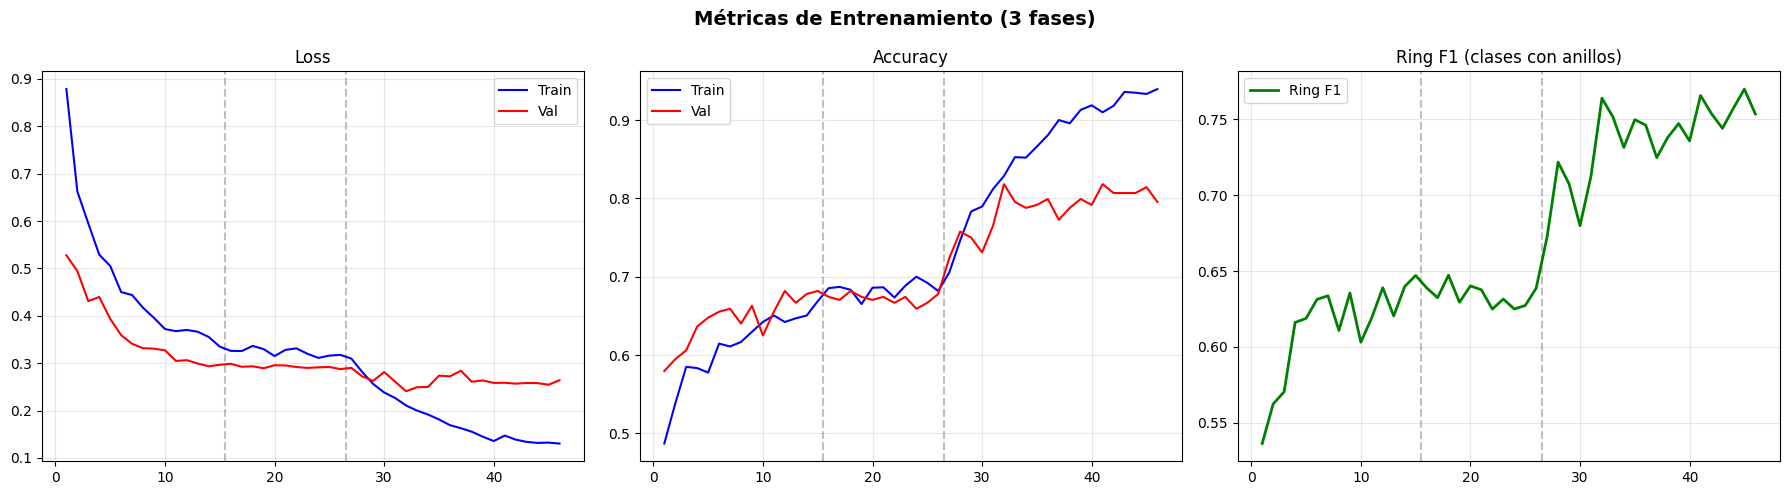

In [19]:
def plot_training_history(*histories, labels=None):
    all_train_loss, all_val_loss = [], []
    all_train_acc, all_val_acc, all_f1 = [], [], []
    for h in histories:
        all_train_loss.extend(h["train_loss"])
        all_val_loss.extend(h["val_loss"])
        all_train_acc.extend(h["train_acc"])
        all_val_acc.extend(h["val_acc"])
        all_f1.extend(h.get("macro_f1", h.get("ring_f1", [])))

    epochs = range(1, len(all_train_loss) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Phase boundaries
    phase_ends = []
    acc = 0
    for h in histories:
        acc += len(h["train_loss"])
        phase_ends.append(acc)

    for ax in axes:
        for pe in phase_ends[:-1]:
            ax.axvline(pe + 0.5, color='gray', linestyle='--', alpha=0.5)

    axes[0].plot(epochs, all_train_loss, 'b-', label='Train')
    axes[0].plot(epochs, all_val_loss, 'r-', label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, all_train_acc, 'b-', label='Train')
    axes[1].plot(epochs, all_val_acc, 'r-', label='Val')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, all_f1, 'g-', linewidth=2, label='Ring F1')
    axes[2].set_title('Ring F1 (clases con anillos)'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle("Métricas de Entrenamiento (3 fases)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_history(history_f1, history_f2, history_f3)

## 9.5 Evaluación final del modelo

Cargando: best_ring_sub_phase3_f177.pt
Modelo cargado: best_ring_sub_phase3_f177.pt

              precision    recall  f1-score   support

       inner       0.87      0.85      0.86       160
       outer       0.66      0.66      0.66        35
 inner+outer       0.78      0.81      0.79        69

    accuracy                           0.81       264
   macro avg       0.77      0.77      0.77       264
weighted avg       0.82      0.81      0.81       264



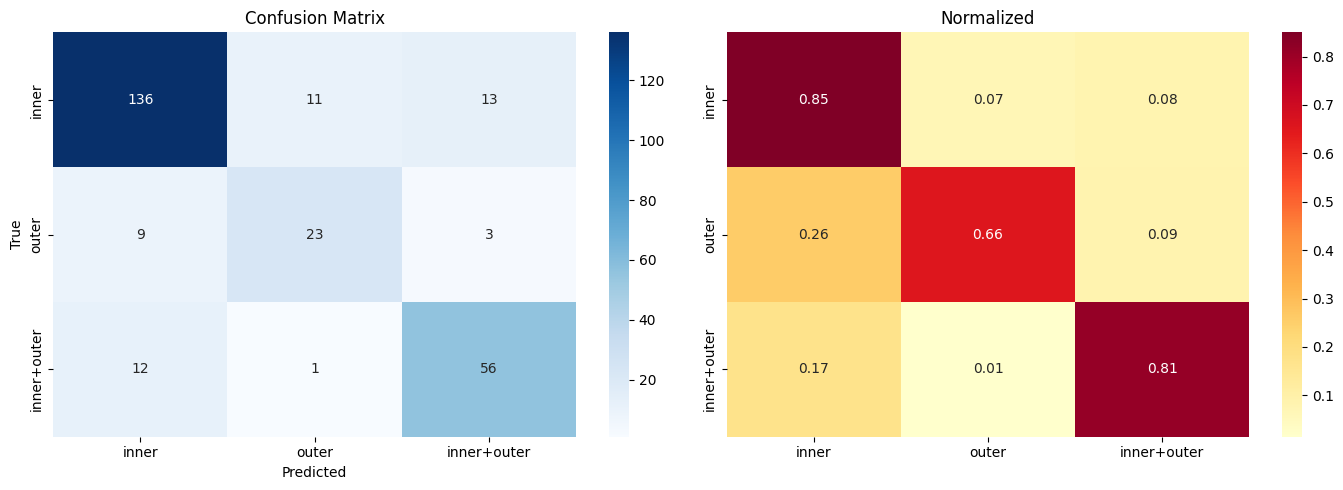


  Macro F1: 0.7698 | Weighted F1: 0.8148


In [20]:
import glob as glob_mod
best_models = sorted(glob_mod.glob("best_ring_sub_*.pt"))
if best_models:
    print(f"Cargando: {best_models[-1]}")
    model.load_model(best_models[-1])
report = model.evaluate(val_dataloader, plot=True)

---
# Parte 10: Inferencia por clase


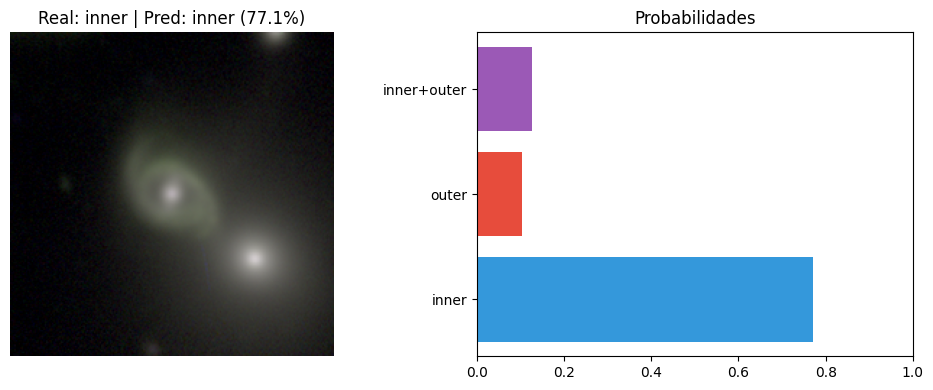

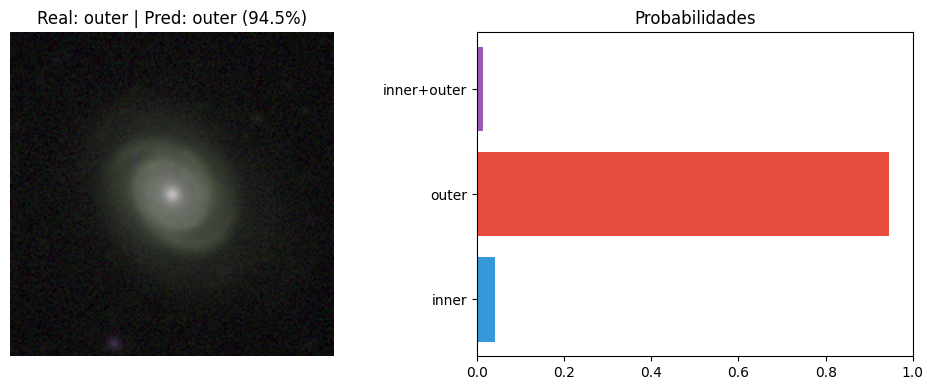

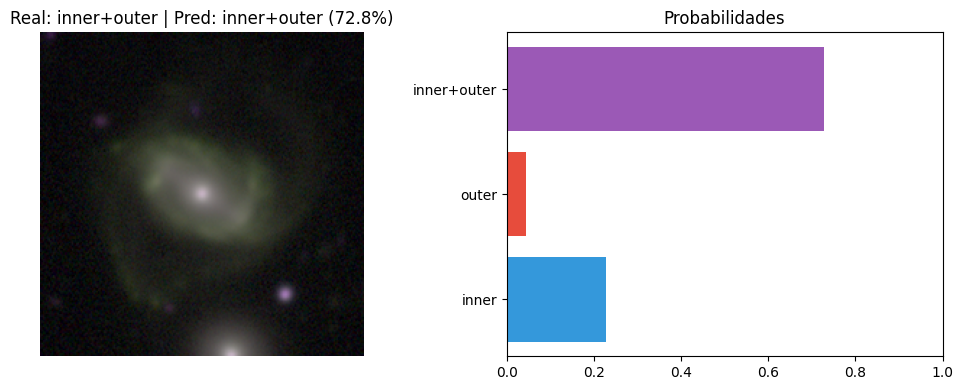

In [21]:
# Probar con muestras de cada clase
for cls_name in RING_TYPE:
    cls_dir = DATA_DIR / cls_name
    imgs = sorted(cls_dir.glob('*.png'))
    if imgs:
        sample = random.choice(imgs)
        img = Image.open(sample).convert('RGB')
        tensor = val_transform(img).unsqueeze(0).to(model.device)
        model.eval()
        with torch.no_grad():
            out = model(tensor)
            probs = F.softmax(out, dim=1).cpu().numpy()[0]
            pred_idx = int(np.argmax(probs))
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(img); axes[0].axis('off')
        axes[0].set_title(f'Real: {cls_name} | Pred: {RING_TYPE[pred_idx]} ({probs[pred_idx]:.1%})', fontsize=12)
        colors = ['#3498db', '#e74c3c', '#9b59b6']
        axes[1].barh(RING_TYPE, probs, color=colors)
        axes[1].set_xlim(0, 1); axes[1].set_title('Probabilidades')
        plt.tight_layout(); plt.show()


Visualizando muestras con detección de anillos v3...


 Clase: INNER


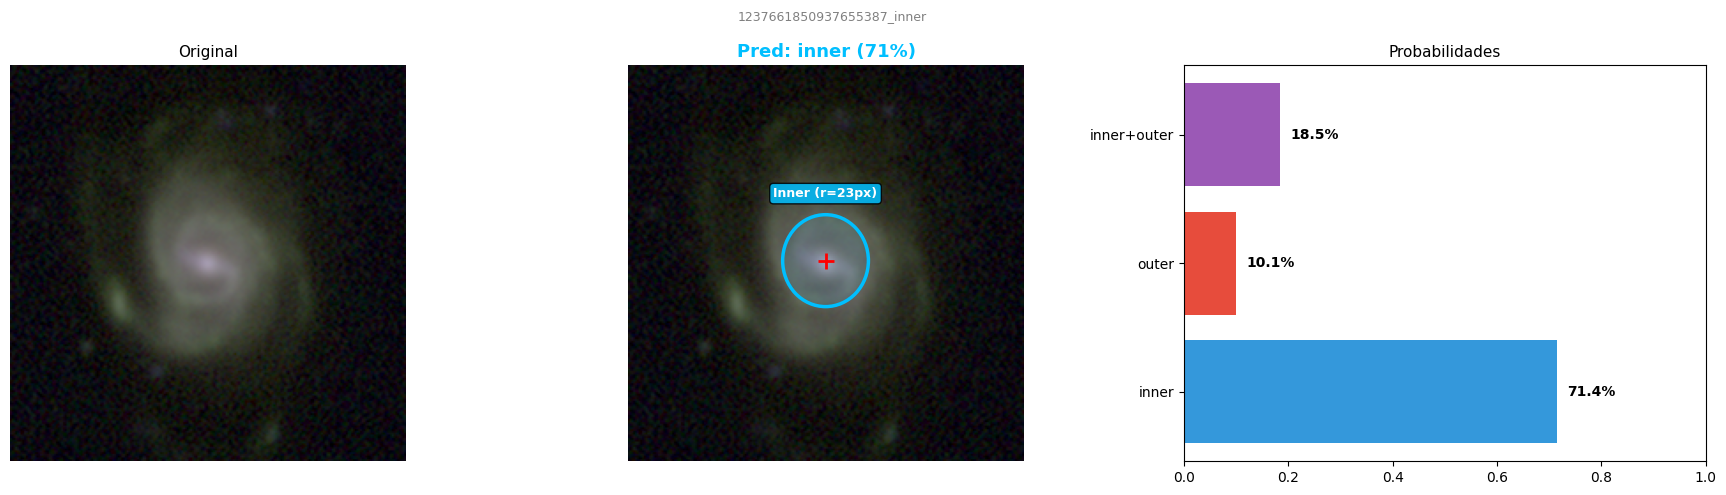

  Inner ring (detectado): r=23px, a=26.0, b=24.3


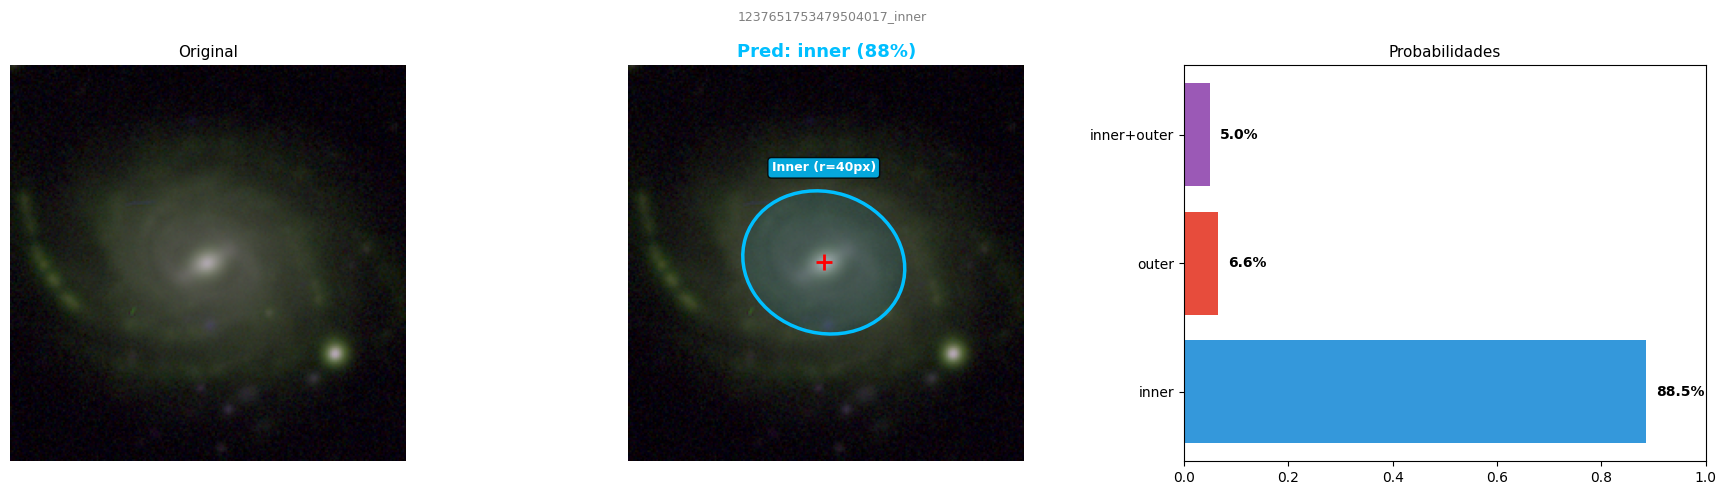

  Inner ring (detectado): r=40px, a=46.4, b=39.8


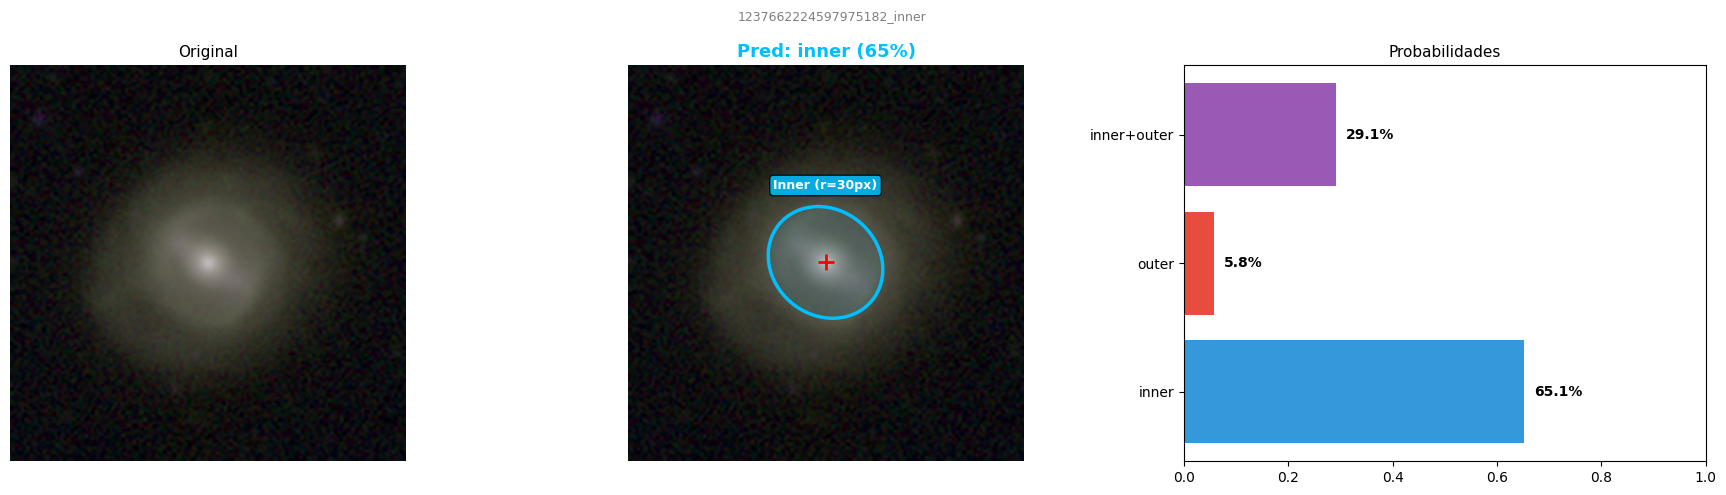

  Inner ring (detectado): r=30px, a=34.0, b=29.9

 Clase: OUTER


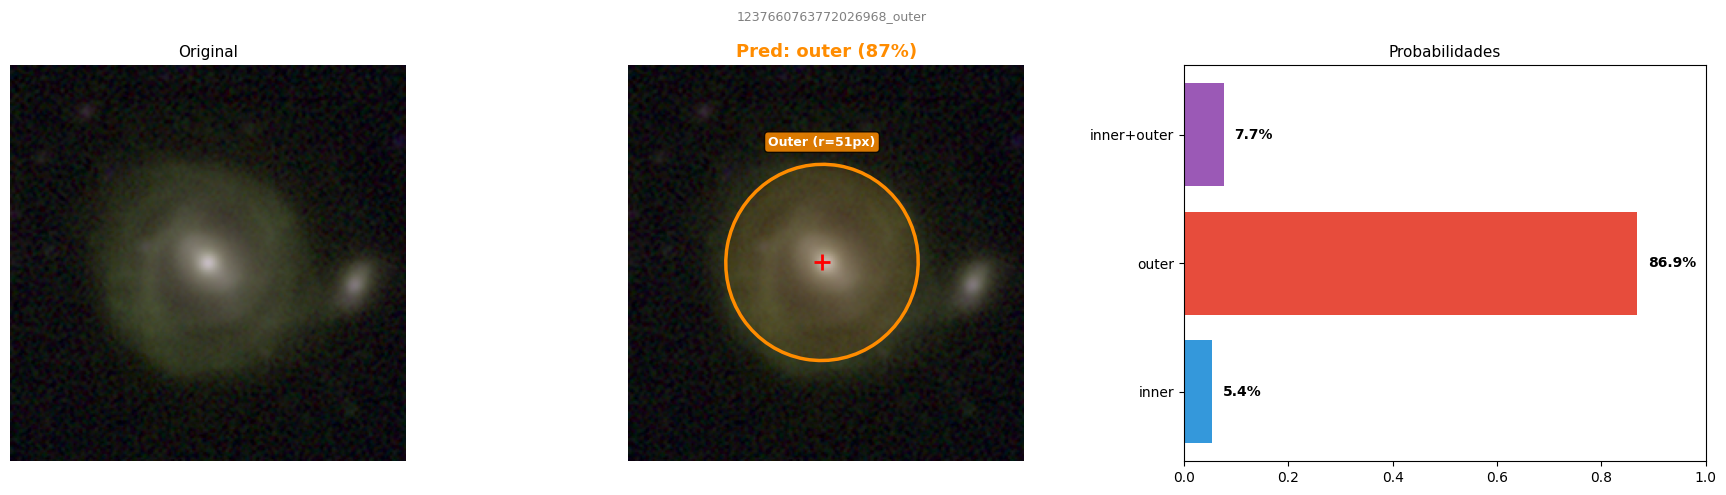

  Outer ring (detectado): r=51px, a=55.5, b=54.4


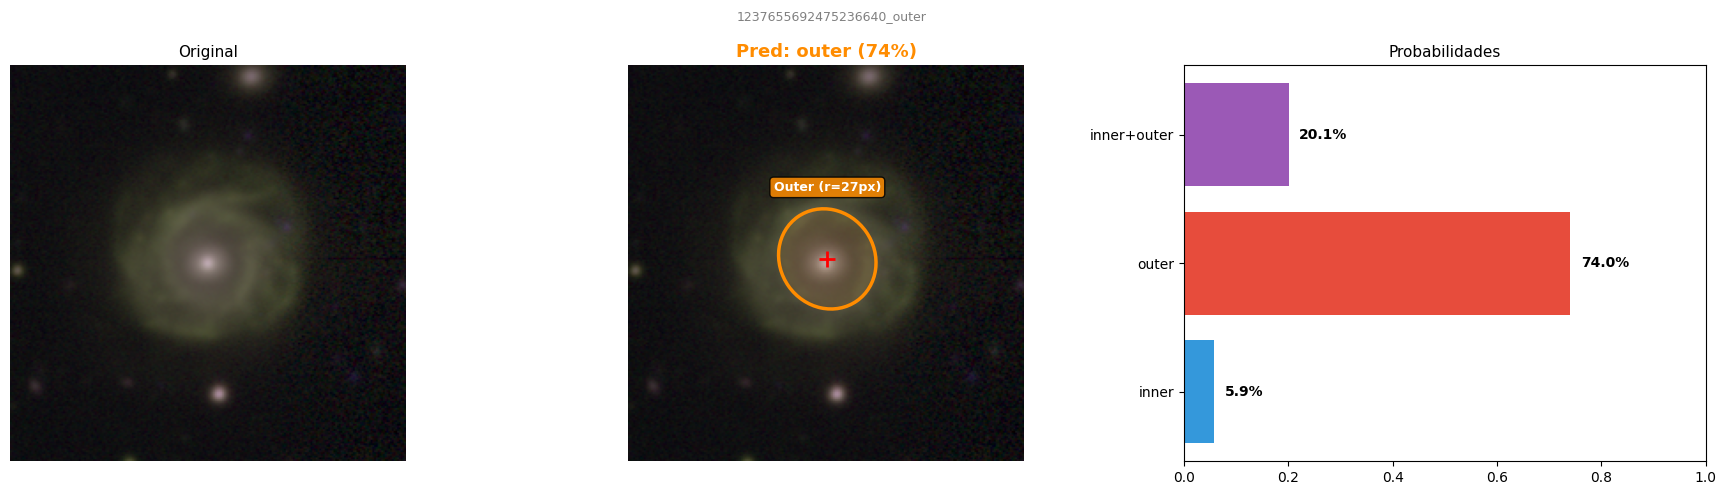

  Outer ring (detectado): r=27px, a=29.1, b=26.8


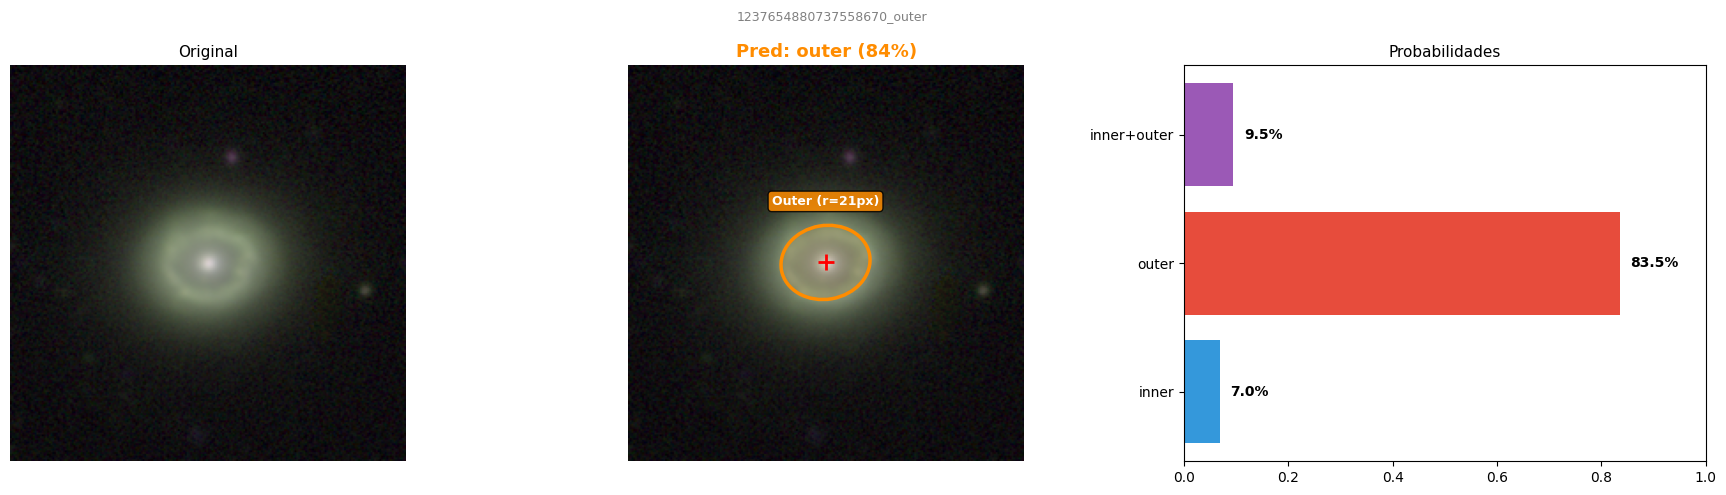

  Outer ring (detectado): r=21px, a=25.3, b=20.9

 Clase: INNER+OUTER


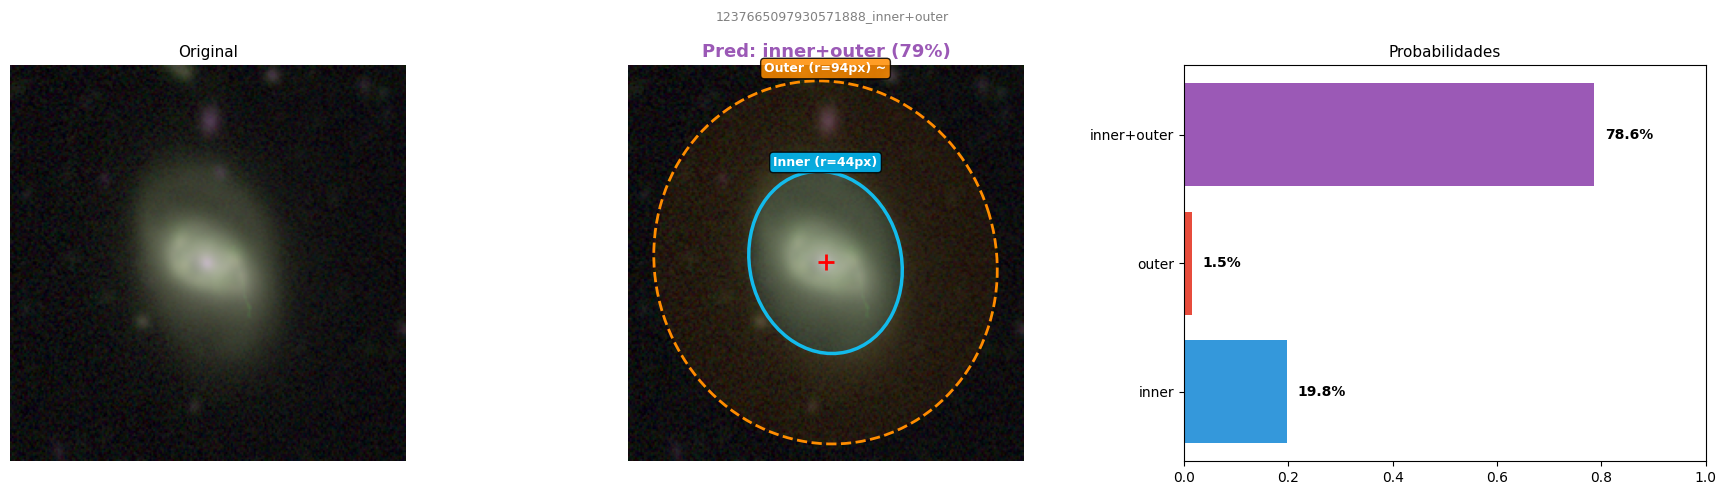

  Inner ring (detectado): r=44px, a=52.0, b=42.9
  Outer ring (estimado): r=94px, a=103.3, b=96.5


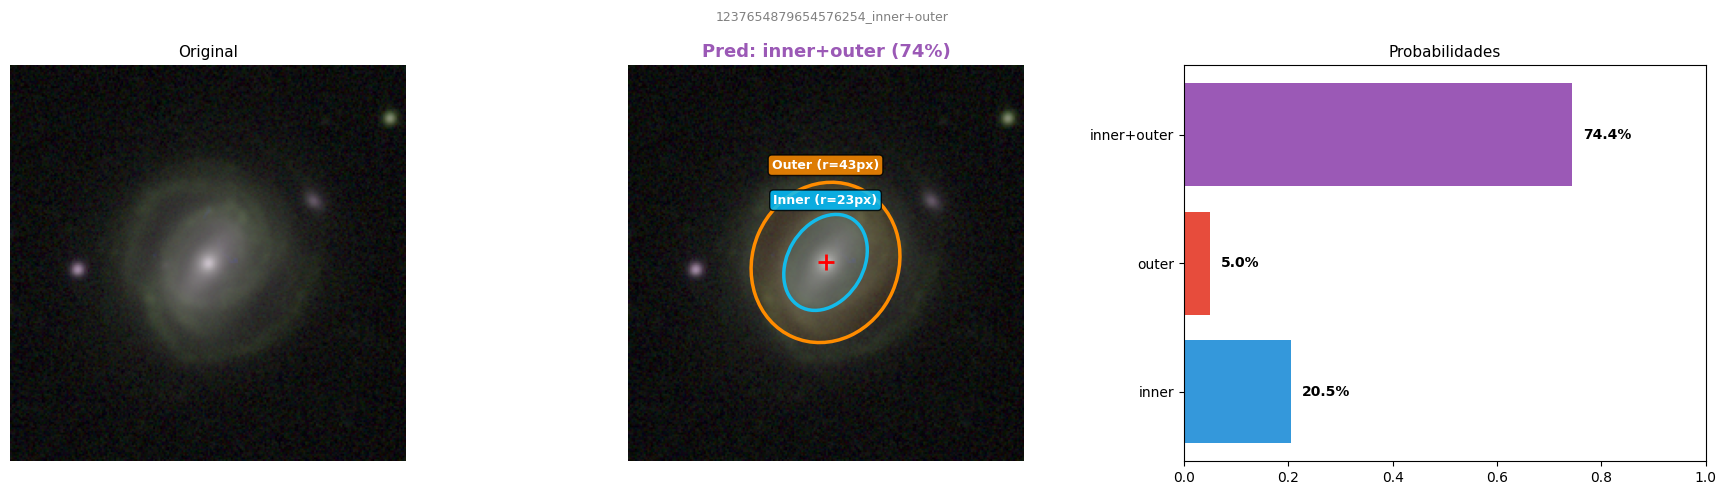

  Inner ring (detectado): r=23px, a=28.9, b=21.5
  Outer ring (detectado): r=43px, a=46.1, b=41.3


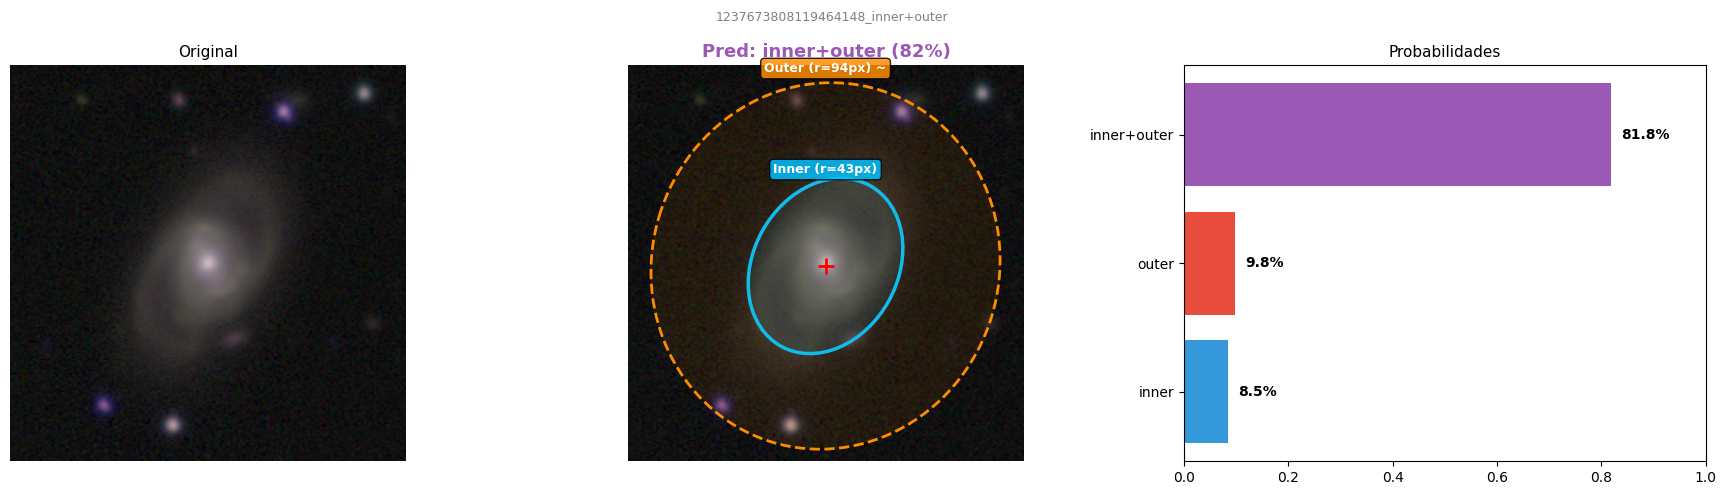

  Inner ring (detectado): r=43px, a=51.9, b=40.9
  Outer ring (estimado): r=94px, a=104.1, b=98.2


In [ ]:
# ============================================================
# visualización de anillos
# ============================================================
from skimage.measure import label, regionprops
from skimage.filters import gaussian
from skimage.morphology import binary_closing, binary_opening, disk
from scipy.signal import savgol_filter, find_peaks
from scipy.ndimage import center_of_mass
from matplotlib.patches import Ellipse

def find_galaxy_center(gray):
    """Centro robusto: gaussiana amplia + centroide ponderado."""
    h, w = gray.shape
    very_smooth = gaussian(gray, sigma=15)
    cy_r, cx_r = np.unravel_index(very_smooth.argmax(), very_smooth.shape)
    
    margin = min(60, h//3, w//3)
    y_lo, y_hi = max(0, cy_r - margin), min(h, cy_r + margin)
    x_lo, x_hi = max(0, cx_r - margin), min(w, cx_r + margin)
    
    crop = gaussian(gray[y_lo:y_hi, x_lo:x_hi], sigma=5)
    thresh = np.percentile(crop, 80)
    bright = crop > thresh
    if bright.sum() > 5:
        cy_l, cx_l = center_of_mass(crop * bright)
        cy, cx = int(y_lo + cy_l), int(x_lo + cx_l)
    else:
        cy, cx = cy_r, cx_r
    return int(np.clip(cy, 10, h-10)), int(np.clip(cx, 10, w-10))


def get_galaxy_shape(gray, cy, cx):
    """Obtiene forma global de la galaxia (ángulo, axis ratio, radio efectivo)."""
    h, w = gray.shape
    smoothed = gaussian(gray, sigma=3.0)
    
    # Máscara de la galaxia
    bg = np.percentile(smoothed, 25)
    mask = smoothed > bg
    mask = binary_closing(mask, disk(5))
    mask = binary_opening(mask, disk(3))
    labeled = label(mask.astype(int))
    
    if labeled.max() == 0:
        return 0, 1.0, min(h, w) // 3
    
    # Región que contiene el centro
    regions = regionprops(labeled)
    best = None
    for reg in regions:
        if labeled[cy, cx] == reg.label:
            best = reg
            break
    if best is None:
        best = max(regions, key=lambda r: r.area)
    
    angle = -np.degrees(best.orientation)
    a = best.major_axis_length / 2
    b = best.minor_axis_length / 2
    ratio = b / max(a, 1)
    r_eff = int(np.sqrt(a * b))  # Radio efectivo geométrico
    
    return angle, ratio, r_eff


def fit_ellipse_at_radius(smoothed, cy, cx, radius, galaxy_angle, galaxy_ratio, tol=None):
    """Ajusta una elipse a la isófota en un radio dado usando cv2.fitEllipse."""
    h, w = smoothed.shape
    if tol is None:
        tol = max(5, int(radius * 0.18))
    
    y, x = np.ogrid[:h, :w]
    r_map = np.sqrt((x - cx)**2 + (y - cy)**2)
    annulus = (r_map >= radius - tol) & (r_map <= radius + tol)
    ring_region = smoothed * annulus
    
    valid = ring_region[ring_region > 0]
    if valid.size < 15:
        # Fallback: usar forma de la galaxia
        return radius, radius * galaxy_ratio, galaxy_angle
    
    thresh = np.percentile(valid, 30)
    binary = ((ring_region > thresh) & annulus).astype(np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5)))
    
    # Encontrar contornos y ajustar elipse
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return radius, radius * galaxy_ratio, galaxy_angle
    
    # Juntar todos los puntos de contorno
    all_points = np.vstack(contours)
    
    if len(all_points) >= 5:
        try:
            (ex, ey), (axis_min, axis_max), angle_cv = cv2.fitEllipse(all_points)
            semi_a = max(axis_max, axis_min) / 2
            semi_b = min(axis_max, axis_min) / 2
            # cv2 angle: desde eje Y, sentido horario → convertir
            angle = -(angle_cv - 90)
            
            # Sanity checks
            if semi_a < 3 or semi_a > max(h, w):
                return radius, radius * galaxy_ratio, galaxy_angle
            if semi_b / semi_a < 0.1:
                semi_b = semi_a * galaxy_ratio
            
            return semi_a, semi_b, angle
        except cv2.error:
            pass
    
    return radius, radius * galaxy_ratio, galaxy_angle


def detect_rings_v3(img_rgb, predicted_class):
    """Detecta anillos con centrado robusto, forma de galaxia, y cv2.fitEllipse."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.float64) / 255.0
    h, w = gray.shape
    cy, cx = find_galaxy_center(gray)
    galaxy_angle, galaxy_ratio, r_eff = get_galaxy_shape(gray, cy, cx)
    
    smoothed = gaussian(gray, sigma=2.0)
    
    # Imagen residual
    smooth_model = gaussian(gray, sigma=12)
    residual = gray - smooth_model
    rmin, rmax = residual.min(), residual.max()
    if rmax > rmin:
        residual = (residual - rmin) / (rmax - rmin)
    residual = gaussian(residual, sigma=1.5)
    
    # Perfil radial del residual
    y, x = np.ogrid[:h, :w]
    r_map = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    max_r = max(min(cy, cx, h - cy, w - cx), 20)
    radii = np.arange(0, max_r)
    
    res_profile = np.array([np.median(residual[r_map == r]) if np.any(r_map == r) else 0 for r in radii])
    
    if len(res_profile) >= 7:
        win = min(15, len(res_profile) // 5)
        if win % 2 == 0: win += 1
        win = max(5, win)
        res_smooth = savgol_filter(res_profile, win, 3)
    else:
        res_smooth = res_profile
    
    # Detectar picos
    skip = max(5, int(len(res_smooth) * 0.08))
    search = res_smooth[skip:]
    peak_radii = []
    if len(search) > 5:
        dyn_range = search.max() - search.min()
        peaks, props = find_peaks(search, distance=max(5, len(search)//8),
                                  prominence=max(dyn_range * 0.025, 0.001), width=2)
        peak_radii = [int(radii[p + skip]) for p in peaks if (p + skip) < len(radii)]
    
    # Ajustar elipses en cada pico detectado
    ellipses = []
    for rpx in peak_radii:
        if rpx < 5 or rpx > max_r * 0.95:
            continue
        semi_a, semi_b, angle = fit_ellipse_at_radius(smoothed, cy, cx, rpx, galaxy_angle, galaxy_ratio)
        ellipses.append({
            'semi_a': semi_a, 'semi_b': semi_b, 'angle': angle,
            'radius_px': rpx, 'detected': True
        })
    
    # Limitar el radio máximo al borde real de la galaxia
    max_ring_r = min(max_r * 0.85, r_eff * 1.5)
    
    # Construir resultado según la clase predicha
    ellipses.sort(key=lambda e: e['radius_px'])
    # Filtrar elipses fuera de rango
    ellipses = [e for e in ellipses if 5 < e['radius_px'] < max_ring_r]
    
    result = []
    
    if predicted_class == 'inner':
        if ellipses:
            e = ellipses[0]
            e['type'] = 'Inner'
            result = [e]
        else:
            r = max(8, int(r_eff * 0.35))
            sa, sb, ang = fit_ellipse_at_radius(smoothed, cy, cx, r, galaxy_angle, galaxy_ratio)
            result = [{'semi_a': sa, 'semi_b': sb, 'angle': ang,
                       'radius_px': r, 'type': 'Inner', 'detected': False}]
    
    elif predicted_class == 'outer':
        if ellipses:
            e = ellipses[-1]
            e['type'] = 'Outer'
            result = [e]
        else:
            r = max(15, int(min(r_eff * 0.9, max_ring_r * 0.8)))
            sa, sb, ang = fit_ellipse_at_radius(smoothed, cy, cx, r, galaxy_angle, galaxy_ratio)
            result = [{'semi_a': sa, 'semi_b': sb, 'angle': ang,
                       'radius_px': r, 'type': 'Outer', 'detected': False}]
    
    elif predicted_class == 'inner+outer':
        if len(ellipses) >= 2:
            # Asegurar separación mínima
            inner_e = ellipses[0]
            outer_e = ellipses[-1]
            if outer_e['radius_px'] > inner_e['radius_px'] * 1.5:
                inner_e['type'] = 'Inner'
                outer_e['type'] = 'Outer'
                result = [inner_e, outer_e]
            else:
                # Los 2 están muy juntos, usar solo el menor como inner y crear outer
                inner_e['type'] = 'Inner'
                r_out = max(inner_e['radius_px'] * 2.2, int(min(r_eff * 0.9, max_ring_r * 0.8)))
                r_out = int(min(r_out, max_ring_r))
                sa, sb, ang = fit_ellipse_at_radius(smoothed, cy, cx, int(r_out), galaxy_angle, galaxy_ratio)
                outer_e = {'semi_a': sa, 'semi_b': sb, 'angle': ang,
                           'radius_px': int(r_out), 'type': 'Outer', 'detected': False}
                result = [inner_e, outer_e]
        elif len(ellipses) == 1:
            e = ellipses[0]
            if e['radius_px'] < r_eff * 0.5:
                # Es el inner, crear outer
                e['type'] = 'Inner'
                r_out = int(min(max(e['radius_px'] * 2.5, r_eff * 0.85), max_ring_r))
                sa, sb, ang = fit_ellipse_at_radius(smoothed, cy, cx, r_out, galaxy_angle, galaxy_ratio)
                outer = {'semi_a': sa, 'semi_b': sb, 'angle': ang,
                         'radius_px': r_out, 'type': 'Outer', 'detected': False}
                result = [e, outer]
            else:
                # Es el outer, crear inner
                e['type'] = 'Outer'
                r_in = max(8, int(e['radius_px'] * 0.35))
                sa, sb, ang = fit_ellipse_at_radius(smoothed, cy, cx, r_in, galaxy_angle, galaxy_ratio)
                inner = {'semi_a': sa, 'semi_b': sb, 'angle': ang,
                         'radius_px': r_in, 'type': 'Inner', 'detected': False}
                result = [inner, e]
        else:
            # Ningún pico: crear ambos basados en la galaxia
            r_in = max(8, int(r_eff * 0.35))
            r_out = int(min(r_eff * 0.9, max_ring_r))
            sa_i, sb_i, ang_i = fit_ellipse_at_radius(smoothed, cy, cx, r_in, galaxy_angle, galaxy_ratio)
            sa_o, sb_o, ang_o = fit_ellipse_at_radius(smoothed, cy, cx, r_out, galaxy_angle, galaxy_ratio)
            result = [
                {'semi_a': sa_i, 'semi_b': sb_i, 'angle': ang_i,
                 'radius_px': r_in, 'type': 'Inner', 'detected': False},
                {'semi_a': sa_o, 'semi_b': sb_o, 'angle': ang_o,
                 'radius_px': r_out, 'type': 'Outer', 'detected': False},
            ]
    
    return result, (cy, cx)


def visualize_galaxy_rings(model, img_path, show_probs=True):
    """Predice clase y dibuja anillos con cv2.fitEllipse."""
    model.eval()
    img = Image.open(img_path).convert('RGB')
    img_rgb = np.array(img)
    tensor = val_transform(img).unsqueeze(0).to(model.device)
    
    with torch.no_grad():
        output = model(tensor)
        probs = F.softmax(output, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))
        pred_class = RING_TYPE[pred_idx]
        confidence = probs[pred_idx]
    
    rings, (cy, cx) = detect_rings_v3(img_rgb, pred_class)
    ring_colors = {'Inner': '#00BFFF', 'Outer': '#FF8C00'}
    
    ncols = 3 if show_probs else 2
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original', fontsize=11)
    axes[0].axis('off')
    
    axes[1].imshow(img_rgb)
    axes[1].plot(cx, cy, 'r+', markersize=12, markeredgewidth=2)
    
    for ring in rings:
        rtype = ring['type']
        color = ring_colors.get(rtype, '#FFFF00')
        detected = ring.get('detected', True)
        ls = '-' if detected else '--'
        lw = 2.5 if detected else 2.0
        
        e_patch = Ellipse(xy=(cx, cy), width=ring['semi_a']*2, height=ring['semi_b']*2,
                         angle=-ring['angle'], fill=False, edgecolor=color, linewidth=lw, linestyle=ls)
        axes[1].add_patch(e_patch)
        e_fill = Ellipse(xy=(cx, cy), width=ring['semi_a']*2, height=ring['semi_b']*2,
                        angle=-ring['angle'], fill=True, facecolor=color, alpha=0.08)
        axes[1].add_patch(e_fill)
        
        label_y = cy - ring['semi_b'] - 10
        tag = '' if detected else ' ~'
        axes[1].annotate(f"{rtype} (r={ring['radius_px']}px){tag}",
                        xy=(cx, max(5, label_y)), fontsize=9, color='white',
                        fontweight='bold', ha='center', va='bottom',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.85))
    
    title_color = {'inner': '#00BFFF', 'outer': '#FF8C00', 'inner+outer': '#9b59b6'}
    axes[1].set_title(f'Pred: {pred_class} ({confidence:.0%})', fontsize=13,
                     fontweight='bold', color=title_color.get(pred_class, 'black'))
    axes[1].axis('off')
    
    if show_probs:
        colors_bar = ['#3498db', '#e74c3c', '#9b59b6']
        bars = axes[2].barh(RING_TYPE, probs, color=colors_bar)
        axes[2].set_xlim(0, 1)
        axes[2].set_title('Probabilidades', fontsize=11)
        for bar, p in zip(bars, probs):
            axes[2].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                        f'{p:.1%}', va='center', fontweight='bold', fontsize=10)
    
    fname = Path(img_path).stem[:35]
    plt.suptitle(fname, fontsize=9, color='gray')
    plt.tight_layout()
    plt.show()
    return {'class': pred_class, 'confidence': float(confidence), 'rings': rings}


# ============================================================
# Visualizar muestras de cada clase
# ============================================================
print('Visualizando muestras con detección de anillos v3...\n')
for cls_name in RING_TYPE:
    cls_dir = DATA_DIR / cls_name
    imgs = sorted(cls_dir.glob('*.png'))
    if not imgs: continue
    print(f'\n{"="*50}')
    print(f' Clase: {cls_name.upper()}')
    print(f'{"="*50}')
    samples = random.sample(imgs, min(3, len(imgs)))
    for img_path in samples:
        result = visualize_galaxy_rings(model, img_path)
        for r in result['rings']:
            det = 'detectado' if r.get('detected', True) else 'estimado'
            print(f'  {r["type"]} ring ({det}): r={r["radius_px"]}px, '
                  f'a={r["semi_a"]:.1f}, b={r["semi_b"]:.1f}')

---
# Parte 11: Exportar


In [26]:
final_path = OUTPUT_DIR / 'zoobot_ring_subclassifier_v7_final.pt'
model.save_model(str(final_path))
print('Exportado')


Modelo guardado: outputs\zoobot_ring_subclassifier_v7_final.pt
Exportado
